In [1]:
!mkdir -p ~/.kaggle

In [3]:
!mv kaggle.json ~/.kaggle/

In [4]:
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d jtiptj/chest-xray-pneumoniacovid19tuberculosis

Dataset URL: https://www.kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis
License(s): other
 99% 1.72G/1.74G [00:11<00:00, 223MB/s]
100% 1.74G/1.74G [00:11<00:00, 162MB/s]


In [6]:
!unzip /content/chest-xray-pneumoniacovid19tuberculosis.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/train/NORMAL/NORMAL2-IM-0843-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0845-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0846-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0847-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0848-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0849-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001-0002.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0851-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0852-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0853-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0854-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0855-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0856-0001.jpeg  
  inflating: /content/train/NORMAL/NORMAL2-IM-0857-0001.j

In [7]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.layers import Rescaling

#for Reproducibility
import numpy as np
import random
import os
seed=123
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [8]:
#Directoried containing the dataset

train_dir="/content/train/"
test_dir="/content/test/"
val_dir="/content/val/"

#Hyper Parameters
img_width,img_height=224,224
batch_size=32
epochs=20
num_classes=4 # Update based on your dataset

In [9]:
#Load the datasets without validation split
train_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size,
    shuffle=True
)

Found 6326 files belonging to 4 classes.


In [10]:
validation_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size,
)

Found 38 files belonging to 4 classes.


In [11]:
test_dataset=tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_width,img_height),
    batch_size=batch_size,
)

Found 771 files belonging to 4 classes.


In [12]:
#Data Augmentation

data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [13]:
#Apply data augmentation onlt to the training data
train_dataset=train_dataset.map(lambda x,y:(data_augmentation(x,training=True),y))

#prefetch the datasets for better perfromanec
AUTOTUNE=tf.data.AUTOTUNE
train_dataset=train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset=validation_dataset.prefetch(buffer_size=AUTOTUNE)

- Machine Learning Pipeline Steps

    - Data Preparation
        
        Get the dataset: Acquire the dataset (e.g., from files, APIs, or databases).

        Normalise the dataset: Scale features (e.g., MinMax, StandardScaler).

        Use validation split: Reserve a portion of data for validation (e.g., train_test_split).

    - Data Pipeline Optimization

        Initialise generators: Set up data generators (e.g., tf.data.Dataset or ImageDataGenerator).

        Data Augmentation: Apply transformations (e.g., rotation, flipping) to improve generalization.

        Autotune and prefetch: Optimize I/O performance (e.g., tf.data.AUTOTUNE).

    - Model Development

        Model Building: Define architecture (e.g., CNN, LSTM).

        Model summary: Print layer details (e.g., model.summary()).

    - Training & Evaluation

        Model compile: Configure optimizer, loss, metrics (e.g., model.compile()).

        Model training: Fit the model (e.g., model.fit()).

        Model evaluation: Assess performance on train/test/validation sets (e.g., model.evaluate()).

    - Post-Training

        Performance plots and metrics: Visualize accuracy/loss curves, compute metrics (e.g., ROC, F1).

        Model save: Export the model (e.g., model.save() or HDF5 format).

In [14]:
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Rescaling

def build_vgg16(input_shape=(224,224,3), num_classes=4):
    model = models.Sequential()

    # Input Layer with Normalization
    model.add(layers.Input(shape=input_shape))
    model.add(Rescaling(1./255))  # Normalize pixel values to [0,1]

    # Block 1
    model.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(64, (3,3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2,2), strides=(2,2)))  # Fixed syntax

    # Block 2
    model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2,2), strides=(2,2)))

    # Block 3
    model.add(layers.Conv2D(256, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(256, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(256, (3,3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2,2), strides=(2,2)))

    # Block 4
    model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2,2), strides=(2,2)))

    # Block 5
    model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu"))
    model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu"))
    model.add(layers.MaxPooling2D((2,2), strides=(2,2)))

    # Fully Connected Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(4096, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4096, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

In [15]:
model=build_vgg16(num_classes=num_classes)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,38

 Total params: 134,276,932 (512.23 MB)

 Trainable params: 134,276,932 (512.23 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
#Use 'categorixal_crossentropy' if labels are one-hot encoded

In [ ]:
history=model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=validation_dataset
)

Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.5592 - loss: 1.3771 - val_accuracy: 0.2105 - val_loss: 1.8183
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 174s 805ms/step - accuracy: 0.6110 - loss: 1.0618 - val_accuracy: 0.2105 - val_loss: 1.8104
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 159s 799ms/step - accuracy: 0.6136 - loss: 1.0579 - val_accuracy: 0.2105 - val_loss: 1.8404
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 203s 804ms/step - accuracy: 0.6099 - loss: 1.0605 - val_accuracy: 0.2105 - val_loss: 1.8230
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 200s 797ms/step - accuracy: 0.6116 - loss: 1.0577 - val_accuracy: 0.2105 - val_loss: 1.8057
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 160s 806ms/step - accuracy: 0.6120 - loss: 1.0575 - val_accuracy: 0.2105 - val_loss: 1.8157
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 201s 801ms/step - accuracy: 0.6102 - loss: 1.0601 - val_accuracy: 0.2105 - val_loss: 1.8132
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 201s 799ms/step - accuracy: 0.6145 - lo

In [ ]:
#VGG16 is not trained enough, or 20 epochs is not good enough,

In [ ]:
#The thing is model is not trained well good enough , or vgg16 is not good for our task
#VGG16 is properly build on ImageNet Dataset , which doesn;t have any properties like x-ray dataset

In [ ]:
#So at this scenario our custom build vgg16 doesn't work well good enough

In [ ]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range=range(len(epochs))

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training Accuracy')
plt.plot(epochs_range,val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training Loss')
plt.plot(epochs_range,val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

NameError: name 'history' is not defined

In [ ]:
#Isse Humlog dekh lenge ki Training me 1 epoch ke baad model is not learning anything so hume new model hi banana padega and there is very huge diffefence on margin b/w training and validation

In [ ]:
#Maybe we have some images from test dataset to validation dataset to increase the sizeof validation datatset

In [ ]:
#You need to find out ki acha aha pe ilega

In [ ]:
test_loss,test_accuracy=model.evaluate(test_dataset)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

#Train set predictions
y_train_pred=model.predict(train_dataset)
y_train_pred=np.argmax(y_train_pred,axis=1)
y_train=np.concatenate([y for x,y in train_dataset],axis=0)

#Validation set predictions
y_val_pred=model.predict(validation_dataset)
y_val_pred=np.argmax(y_val_pred,axis=1)
y_val=np.concatenate([y for x,y in validation_dataset],axis=0)

#Test set predictions
y_test_pred=model.predict(test_dataset)
y_test_pred=np.argmax(y_test_pred,axis=1)
y_test=np.concatenate([y for x,y in test_dataset],axis=0)


NameError: name 'model' is not defined

In [ ]:
from functools import cmp_to_key
from sklearn.metrics import confusion_matrix

#Confusion matrices
cm_train = confusion_matrix(y_train, y_train_pred)
cm_val = confusion_matrix(y_val, y_val_pred)
cm_test = confusion_matrix(y_test, y_test_pred)

#Set up the figure

fig,axes=plt.subplots(1,3,figsize=(15,5))

#Train Confusion Matix
sns.heatmap(cm_train,annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

#Validation Confusion Matrix
sns.heatmap(cm_train,annot=True,fmt='d',cmap='Blues',ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

#Test Confusion Matrix
sns.heatmap(cm_train,annot=True,fmt='d',cmap='Blues',ax=axes[2])
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Labels')
axes[2].set_ylabel('True Labels')

#Adjust Layout
plt.tight_layout()
plt.show()

## Very Bad Results

## Transfter Learning

In [17]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Input

In [18]:
# Load VGG16 with pre-trained weights, excluding the top (fully connected layers)
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=Input(shape=(img_width, img_height, 3)))

# Print model summary
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#If you keep the include_top=False , then they will not add the 3 fully connected layers to the architechture


In [20]:
#Freeze the layers in the base model
for layer in base_model.layers:
    layer.trainable=False

In [33]:
#Build the model
model=models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes,activation='softmax')
])

In [35]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Transfer learning iwth fixed Weights in convolutions and training model on FC Layers

In [24]:
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_330']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


198/198 ━━━━━━━━━━━━━━━━━━━━ 145s 632ms/step - accuracy: 0.7186 - loss: 4.8252 - val_accuracy: 0.7632 - val_loss: 1.6685
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 114s 568ms/step - accuracy: 0.8613 - loss: 0.7221 - val_accuracy: 0.7632 - val_loss: 1.1985
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 143s 572ms/step - accuracy: 0.8831 - loss: 0.4175 - val_accuracy: 0.7632 - val_loss: 0.9717
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 141s 564ms/step - accuracy: 0.9060 - loss: 0.3247 - val_accuracy: 0.8158 - val_loss: 0.7446
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 141s 563ms/step - accuracy: 0.9036 - loss: 0.2876 - val_accuracy: 0.7895 - val_loss: 0.8411
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 142s 562ms/step - accuracy: 0.9179 - loss: 0.2493 - val_accuracy: 0.8421 - val_loss: 0.6231
Epoch 7/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 112s 566ms/step - accuracy: 0.9169 - loss: 0.2670 - val_accuracy: 0.7632 - val_loss: 1.1090
Epoch 8/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 142s 568ms/step - accuracy: 0.9209 - loss: 0.25

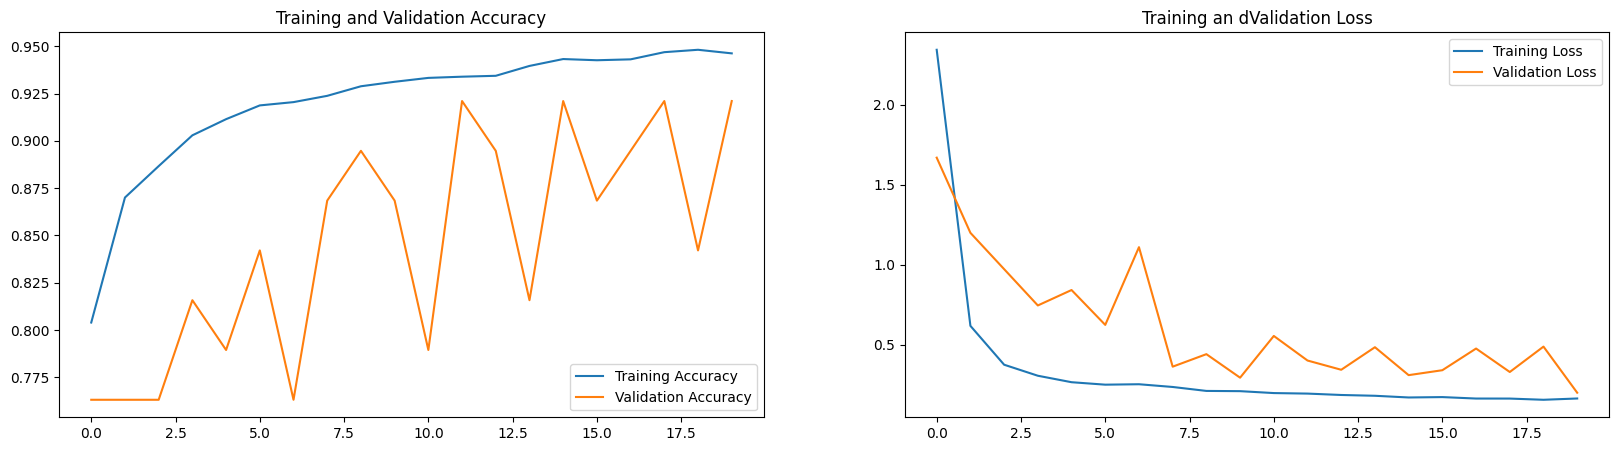

In [27]:
import matplotlib.pyplot as plt

acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs_range=range(epochs)

plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training Accuracy')
plt.plot(epochs_range,val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training Loss')
plt.plot(epochs_range,val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training an dValidation Loss')
plt.show()

In [28]:
test_loss,test_accuracy=model.evaluate(test_dataset)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 318ms/step - accuracy: 0.8700 - loss: 0.5413
Test Accuracy: 88.07%


In [29]:
#Train set predictions
y_train_true=np.concatenate([y for x,y in train_dataset],axis=0)
y_train_pred=model.predict(train_dataset)
y_train_pred=np.argmax(y_train_pred,axis=1)

#Validation set predictions
y_val_true=np.concatenate([y for x,y in validation_dataset],axis=0)
y_val_pred=model.predict(validation_dataset)
y_val_pred=np.argmax(y_val_pred,axis=1)

#Test set predictions
y_test_true=np.concatenate([y for x,y in test_dataset],axis=0)
y_test_pred=model.predict(test_dataset)
y_test_pred=np.argmax(y_test_pred,axis=1)

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_330']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


197/198 ━━━━━━━━━━━━━━━━━━━━ 0s 584ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_330']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


198/198 ━━━━━━━━━━━━━━━━━━━━ 117s 585ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 398ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 252ms/step


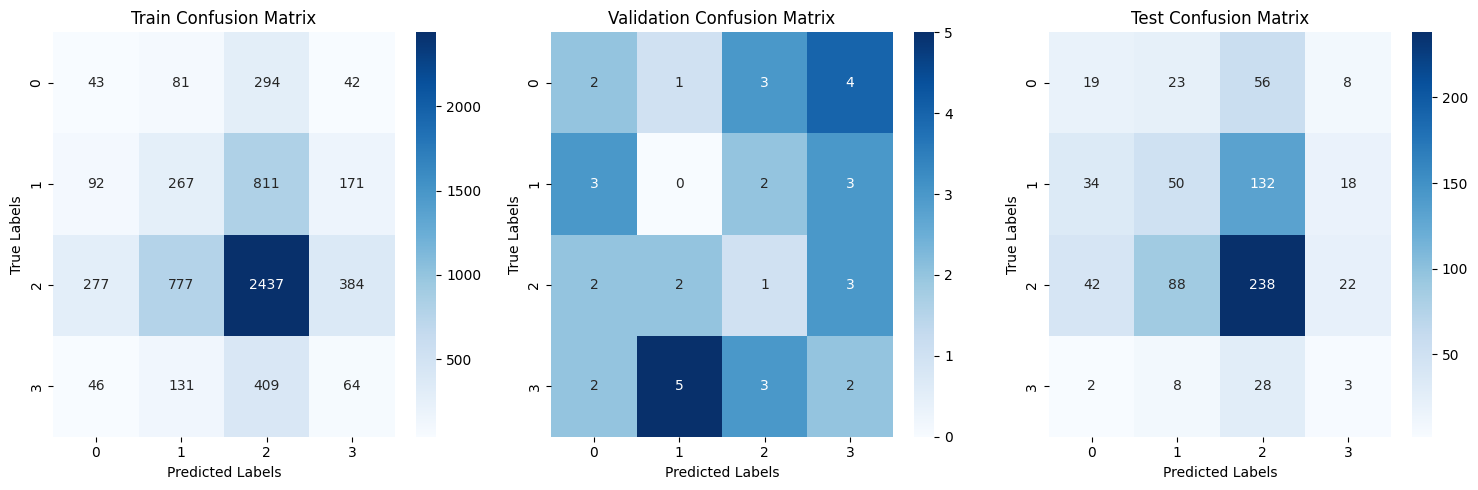

In [30]:
from sklearn.metrics import confusion_matrix

#Confusion Matrix
cm_train=confusion_matrix(y_train_true,y_train_pred)
cm_val=confusion_matrix(y_val_true,y_val_pred)
cm_test=confusion_matrix(y_test_true,y_test_pred)

import seaborn as sns

fig,axes=plt.subplots(1,3,figsize=(15,5))

#Train Confusion Matrix
sns.heatmap(cm_train,annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Train Confusion Matrix')
axes[0].set_xlabel('Predicted Labels')
axes[0].set_ylabel('True Labels')

#Validation Confusion Matrix
sns.heatmap(cm_val,annot=True,fmt='d',cmap='Blues',ax=axes[1])
axes[1].set_title('Validation Confusion Matrix')
axes[1].set_xlabel('Predicted Labels')
axes[1].set_ylabel('True Labels')

#Test Confusion Matrix
sns.heatmap(cm_test,annot=True,fmt='d',cmap='Blues',ax=axes[2])
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted Labels')
axes[2].set_ylabel('True Labels')

#Adjust layout
plt.tight_layout()
plt.show()


## Even More Finetuning

In [31]:
#Load VGG16 with pre-trained ImageNet weights , excluding the top(fully connected layers)
base_model=VGG16(weights='imagenet',include_top=False,input_tensor=Input(shape=(img_width,img_height,3)))

#Freeze the layers in the base model
for layer in base_model.layers[:15]: #Freeze first 15 layers , adjsut as Needed
    layer.trainable=False

#unfreeze the Remaining Layers
for layer in base_model.layers[15:]:
    layer.trainable=True

In [32]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [34]:
#Build the model
model=models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes,activation='softmax')
])

In [36]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history=model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=epochs
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_355']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


198/198 ━━━━━━━━━━━━━━━━━━━━ 126s 601ms/step - accuracy: 0.6753 - loss: 1.7860 - val_accuracy: 0.6842 - val_loss: 0.7192
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 135s 589ms/step - accuracy: 0.8954 - loss: 0.3209 - val_accuracy: 0.6053 - val_loss: 1.1929
Epoch 3/20


In [ ]:
#Load VGG16 with pre-trained ImageNet weights, excluding the top(fully Connected) Layers
base_model=VGG16(weights='imagenet',
                 include_top=False,
                 input_tensor=Input(shape=(img_width,img_height,3)))

#Load VGG16 with pre-trained ImageNet weights , excluding the Top(follu Connected Layers)
base_model2=VGG16(weights='imagenet',
                  include_top=True,
                  input_tensor=Input(shape=(img_width,img_height,3)))
